# **1. Perkenalan Dataset**

Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.

**Dataset yang digunakan:** *Extrovert vs Introvert Behavior Data* (Kaggle).

Dataset ini berisi catatan perilaku sosial seseorang (waktu sendiri, kehadiran event, ukuran lingkaran pertemanan, dll.) dengan label kepribadian `Extrovert` atau `Introvert`. Tujuan eksperimen ini adalah membangun model klasifikasi biner untuk memprediksi kepribadian berdasarkan fitur perilaku, sekaligus mempersiapkan dataset siap-latih yang akan dipakai pada Kriteria 2.

**Fitur:**
- `Time_spent_Alone` — numerik (jam/hari sendirian)
- `Stage_fear` — kategorikal Yes/No
- `Social_event_attendance` — numerik
- `Going_outside` — numerik
- `Drained_after_socializing` — kategorikal Yes/No
- `Friends_circle_size` — numerik
- `Post_frequency` — numerik
- `Personality` — **target** (Extrovert / Introvert)

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

print('numpy :', np.__version__)
print('pandas:', pd.__version__)

numpy : 2.4.6
pandas: 2.3.3


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
RAW_PATH = '../personality_raw/personality_dataset.csv'
df = pd.read_csv(RAW_PATH)
print('Shape:', df.shape)
df.head()

Shape: (1500, 8)


,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,NaN,Yes,2.2,NaN,Yes,0.3,3.3,Introvert
1,3.3,No,7.1,5.3,No,9.3,4.9,Extrovert
2,8.2,No,0.2,0.6,Yes,4.6,0.0,Introvert
3,0.5,No,5.9,4.3,No,10.5,7.9,Extrovert
4,7.0,Yes,0.5,3.4,Yes,0.4,3.3,Introvert


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           1456 non-null   float64
 1   Stage_fear                 1454 non-null   object 
 2   Social_event_attendance    1457 non-null   float64
 3   Going_outside              1449 non-null   float64
 4   Drained_after_socializing  1441 non-null   object 
 5   Friends_circle_size        1459 non-null   float64
 6   Post_frequency             1457 non-null   float64
 7   Personality                1500 non-null   object 
dtypes: float64(5), object(3)
memory usage: 93.9+ KB


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Time_spent_Alone,1456.0,NaN,NaN,NaN,5.433654,3.29905,0.0,2.5,4.9,8.4,11.0
Stage_fear,1454,2,Yes,731,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Social_event_attendance,1457.0,NaN,NaN,NaN,4.575566,2.88603,0.0,2.1,4.4,7.1,10.0
Going_outside,1449.0,NaN,NaN,NaN,3.88744,2.345581,0.0,2.0,3.8,5.7,10.0
Drained_after_socializing,1441,2,No,730,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Friends_circle_size,1459.0,NaN,NaN,NaN,6.612543,4.072805,0.0,3.1,6.2,10.0,15.0
Post_frequency,1457.0,NaN,NaN,NaN,4.338092,2.700597,0.0,2.0,4.1,6.5,10.0
Personality,1500,2,Extrovert,771,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Personality
Extrovert    771
Introvert    729
Name: count, dtype: int64


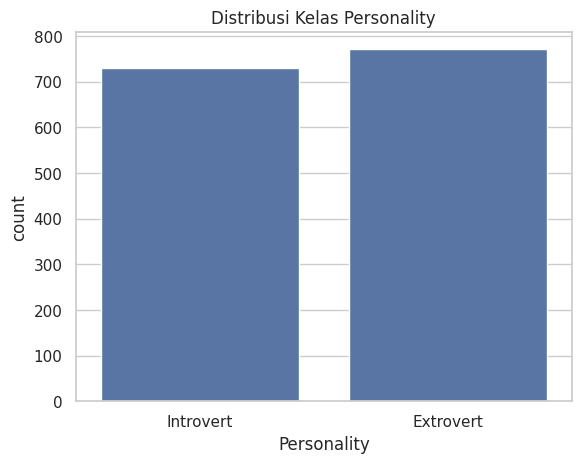

In [5]:
# 4.1 Distribusi target
print(df['Personality'].value_counts(dropna=False))
sns.countplot(data=df, x='Personality')
plt.title('Distribusi Kelas Personality')
plt.show()

Missing per kolom (%):
Drained_after_socializing    3.933333
Going_outside                3.400000
Stage_fear                   3.066667
Time_spent_Alone             2.933333
Social_event_attendance      2.866667
Post_frequency               2.866667
Friends_circle_size          2.733333
Personality                  0.000000
dtype: float64


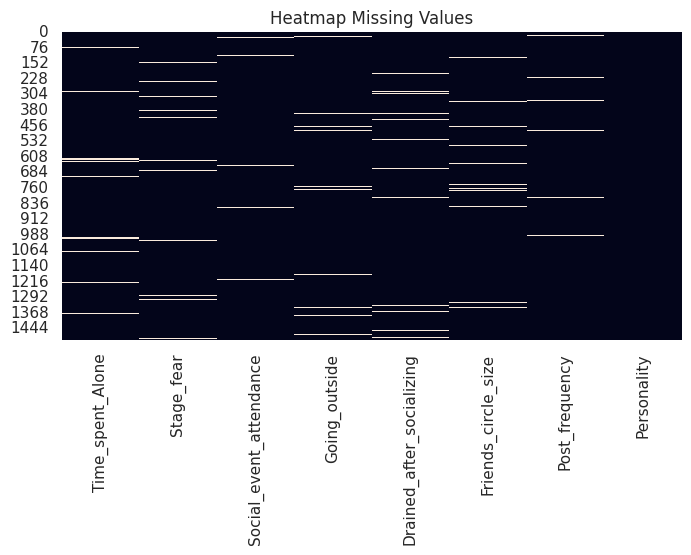

In [6]:
# 4.2 Cek missing values
miss = (df.isna().mean() * 100).sort_values(ascending=False)
print('Missing per kolom (%):')
print(miss)

plt.figure(figsize=(8,4))
sns.heatmap(df.isna(), cbar=False)
plt.title('Heatmap Missing Values')
plt.show()

In [7]:
# 4.3 Cek duplikasi
print('Jumlah baris duplikat:', df.duplicated().sum())

Jumlah baris duplikat: 0


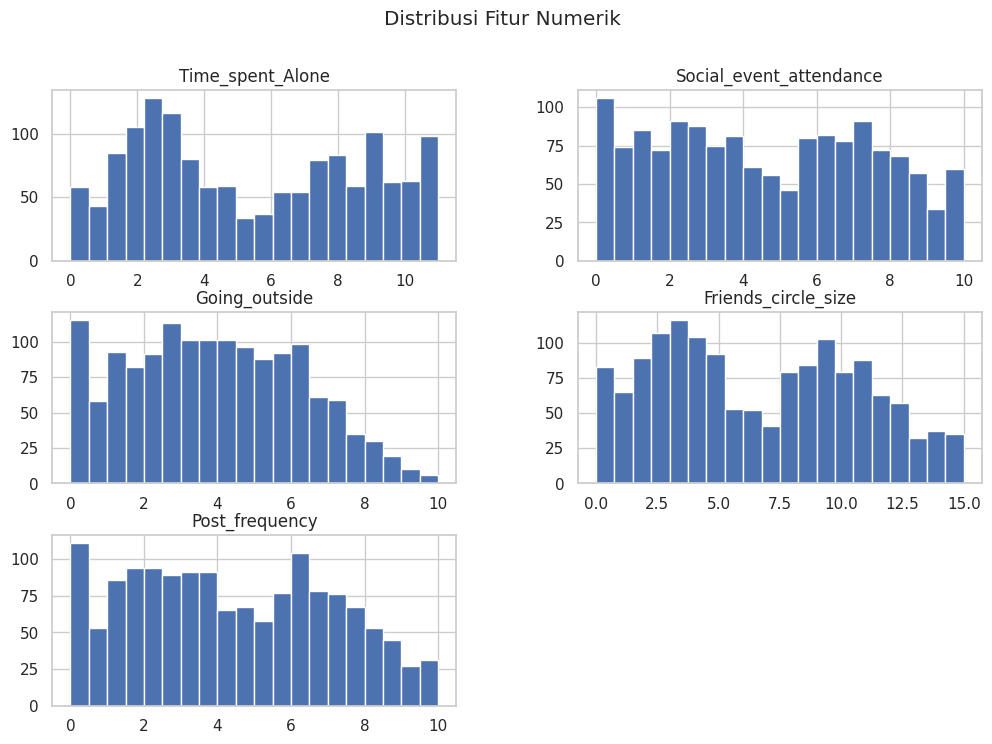

In [8]:
# 4.4 Distribusi fitur numerik
num_cols = ['Time_spent_Alone','Social_event_attendance','Going_outside','Friends_circle_size','Post_frequency']
df[num_cols].hist(bins=20, figsize=(12,8))
plt.suptitle('Distribusi Fitur Numerik')
plt.show()

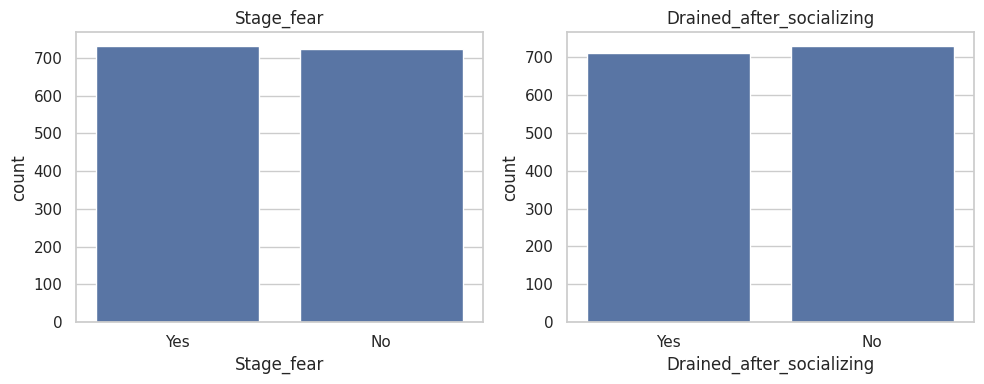

In [9]:
# 4.5 Distribusi fitur kategorikal
cat_cols = ['Stage_fear','Drained_after_socializing']
fig, axes = plt.subplots(1, 2, figsize=(10,4))
for ax, c in zip(axes, cat_cols):
    sns.countplot(data=df, x=c, ax=ax)
    ax.set_title(c)
plt.tight_layout()
plt.show()

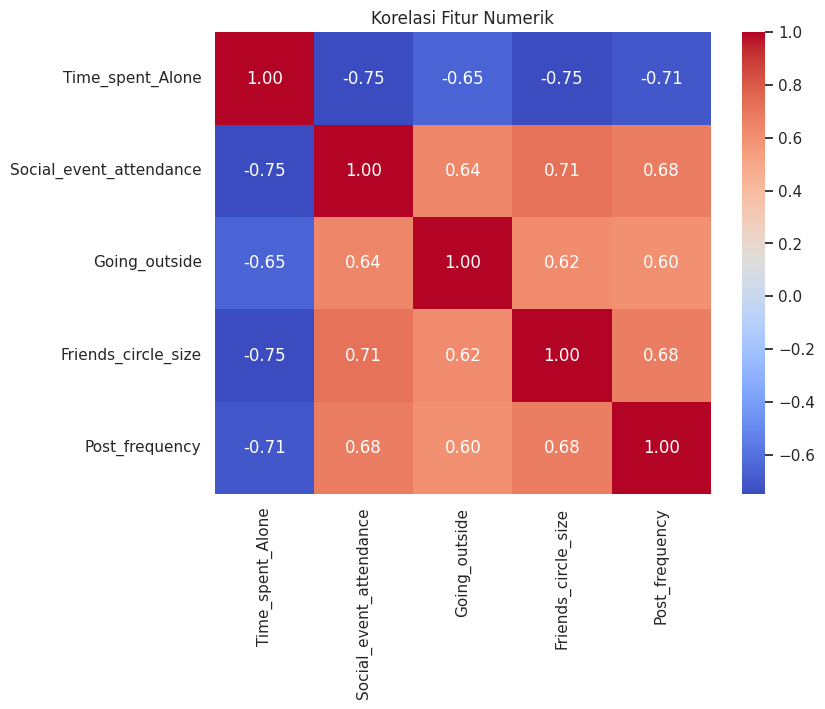

In [10]:
# 4.6 Korelasi antar fitur numerik
corr = df[num_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Fitur Numerik')
plt.show()

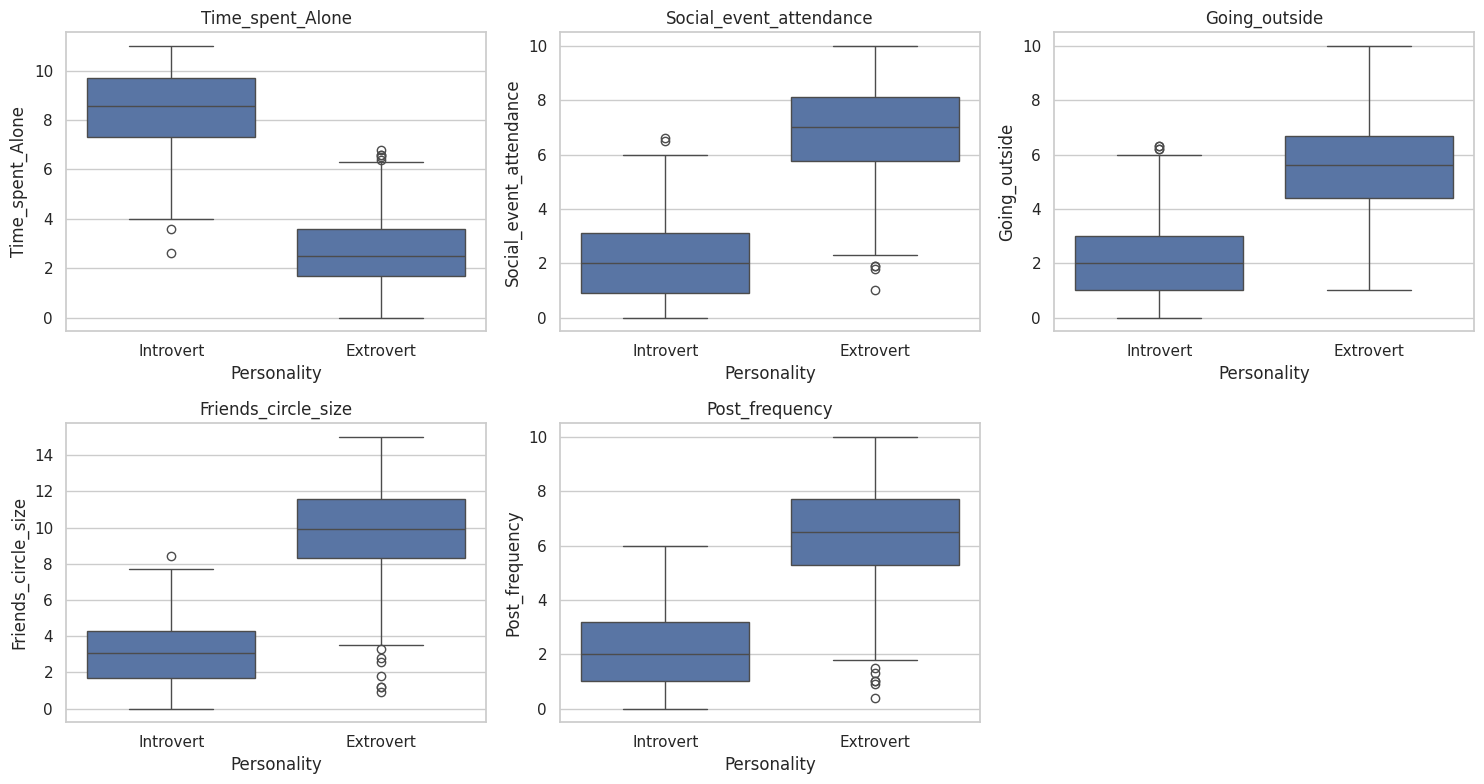

In [11]:
# 4.7 Hubungan fitur numerik dengan target
fig, axes = plt.subplots(2, 3, figsize=(15,8))
for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(data=df, x='Personality', y=col, ax=ax)
    ax.set_title(col)
for ax in axes.flat[len(num_cols):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

In [12]:
# 4.8 Insight singkat
summary = df.groupby('Personality')[num_cols].mean().round(2)
print('Rata-rata fitur numerik per kelas:')
summary

Rata-rata fitur numerik per kelas:


,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
Personality,,,,,
Extrovert,2.60,6.94,5.58,9.97,6.44
Introvert,8.45,2.08,2.07,3.03,2.12


**Insight EDA:**
- Kelas relatif seimbang (~51% Extrovert, ~49% Introvert).
- Terdapat missing values di hampir semua kolom (~3%) — perlu imputasi.
- Fitur `Time_spent_Alone` berkorelasi negatif kuat dengan `Social_event_attendance`, `Going_outside`, `Friends_circle_size`, dan `Post_frequency`. Pola ini selaras dengan label kepribadian.
- Kategorikal `Stage_fear` dan `Drained_after_socializing` sangat diskriminatif (mayoritas Introvert = Yes, Extrovert = No).

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

> **Catatan praktik baik (revisi reviewer):** untuk **mencegah data leakage**, urutan yang benar adalah:
> 1. Bersihkan duplikat & encoding deterministik (`Yes/No → 1/0`, label encoder target).
> 2. **Split train/test terlebih dahulu**.
> 3. **Fit transformer (imputer + scaler) hanya pada data train**, lalu **`transform` saja** untuk data test.
> 4. Bungkus tahap transform dengan `sklearn.Pipeline` + `ColumnTransformer` agar bisa dipakai ulang saat deployment tanpa script terpisah.

In [13]:
# 5.1 Hapus duplikat (operasi safe, tidak bergantung distribusi)
df_clean = df.copy().drop_duplicates().reset_index(drop=True)
print('Shape setelah hapus duplikat:', df_clean.shape)

Shape setelah hapus duplikat: (1500, 8)


In [14]:
# 5.2 Encoding kategorikal deterministik (Yes/No -> 1/0) dan target
# Mapping ini deterministik (bukan dipelajari dari data) sehingga aman dilakukan
# sebelum split. Imputasi numerik dilakukan dulu hanya untuk kolom kategorikal
# agar mapping tidak menghasilkan NaN -> NaN.
df_clean[cat_cols] = df_clean[cat_cols].fillna(df_clean[cat_cols].mode().iloc[0])
for c in cat_cols:
    df_clean[c] = df_clean[c].map({'Yes': 1, 'No': 0}).astype(int)

le = LabelEncoder()
df_clean['Personality'] = le.fit_transform(df_clean['Personality'])
print('Label mapping:', dict(zip(le.classes_, le.transform(le.classes_))))
df_clean.head()

Label mapping: {'Extrovert': np.int64(0), 'Introvert': np.int64(1)}


,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,NaN,1,2.2,NaN,1,0.3,3.3,1
1,3.3,0,7.1,5.3,0,9.3,4.9,0
2,8.2,0,0.2,0.6,1,4.6,0.0,1
3,0.5,0,5.9,4.3,0,10.5,7.9,0
4,7.0,1,0.5,3.4,1,0.4,3.3,1


In [15]:
# 5.3 Deteksi outlier sederhana (IQR) - hanya laporkan, tidak dihapus agar dataset tetap utuh
for col in num_cols:
    series = df_clean[col].dropna()
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((series < lower) | (series > upper)).sum()
    print(f'{col}: {n_out} outlier')

Time_spent_Alone: 0 outlier
Social_event_attendance: 0 outlier
Going_outside: 0 outlier
Friends_circle_size: 0 outlier
Post_frequency: 0 outlier


In [16]:
# 5.4 Split train/test SEBELUM fit transformer (mencegah data leakage)
X = df_clean.drop(columns=['Personality'])
y = df_clean['Personality']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (1200, 7) Test: (300, 7)


In [17]:
# 5.5 Bangun preprocessing Pipeline + ColumnTransformer
# - Kolom numerik: SimpleImputer(median) -> StandardScaler
# - Kolom kategorikal (sudah 0/1): SimpleImputer(most_frequent) (jaga-jaga NaN sisa)
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, num_cols),
        ('cat', categorical_pipeline, cat_cols),
    ]
)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [18]:
# 5.6 fit_transform HANYA pada X_train, transform saja untuk X_test
X_train_arr = preprocessor.fit_transform(X_train)
X_test_arr  = preprocessor.transform(X_test)

feature_order = num_cols + cat_cols
X_train_prep = pd.DataFrame(X_train_arr, columns=feature_order, index=X_train.index)
X_test_prep  = pd.DataFrame(X_test_arr,  columns=feature_order, index=X_test.index)

print('Mean train (harus ~0):')
print(X_train_prep[num_cols].mean().round(3))
print('\nMean test (boleh non-0 -> bukti hanya transform, bukan fit ulang):')
print(X_test_prep[num_cols].mean().round(3))

Mean train (harus ~0):
Time_spent_Alone           0.0
Social_event_attendance   -0.0
Going_outside              0.0
Friends_circle_size        0.0
Post_frequency            -0.0
dtype: float64

Mean test (boleh non-0 -> bukti hanya transform, bukan fit ulang):
Time_spent_Alone           0.001
Social_event_attendance   -0.040
Going_outside              0.002
Friends_circle_size       -0.018
Post_frequency            -0.028
dtype: float64


In [19]:
# 5.7 Simpan hasil preprocessing + fitted pipeline (untuk dipakai langsung di deployment)
OUT_DIR = './personality_preprocessing'
ART_DIR = f'{OUT_DIR}/artifacts'
os.makedirs(ART_DIR, exist_ok=True)

X_train_prep.assign(Personality=y_train.values).to_csv(f'{OUT_DIR}/train.csv', index=False)
X_test_prep.assign(Personality=y_test.values).to_csv(f'{OUT_DIR}/test.csv', index=False)
pd.concat([X_train_prep.assign(Personality=y_train.values),
           X_test_prep.assign(Personality=y_test.values)], ignore_index=True
         ).to_csv(f'{OUT_DIR}/personality_preprocessed.csv', index=False)

joblib.dump(preprocessor, f'{ART_DIR}/preprocessor.joblib')
joblib.dump(le,           f'{ART_DIR}/label_encoder.joblib')
print('Dataset preprocessed + fitted pipeline disimpan ke', OUT_DIR)

Dataset preprocessed + fitted pipeline disimpan ke ./personality_preprocessing
